# Multi-Asset Portfolio Optimisation & Risk Management

## 1. Setup & Data Download

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TICKERS = ['SPY', 'TLT', 'GLD', 'IYR']
START = '2016-03-01'
END = '2026-02-28'
RF = 0.04 # annual risk-free rate
TRADING_DAYS = 252

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.figsize'] = (12, 5)

data = yf.download(TICKERS, start=START, end=END, auto_adjust=True)
prices = data['Close'][TICKERS].dropna()

print(f"Downloaded {len(prices)} trading days  |  {prices.index[0].date()} -> {prices.index[-1].date()}")
prices.tail(3)

[*********************100%***********************]  4 of 4 completed

Downloaded 2514 trading days  |  2016-03-01 -> 2026-02-27


Ticker,SPY,TLT,GLD,IYR
Date,,,,
2026-02-25,691.262207,89.255394,473.420013,100.089073
2026-02-26,687.422607,89.612762,477.480011,100.767166
2026-02-27,684.121643,90.158760,483.750000,100.996521


## 2. Asset Performance Line Chart

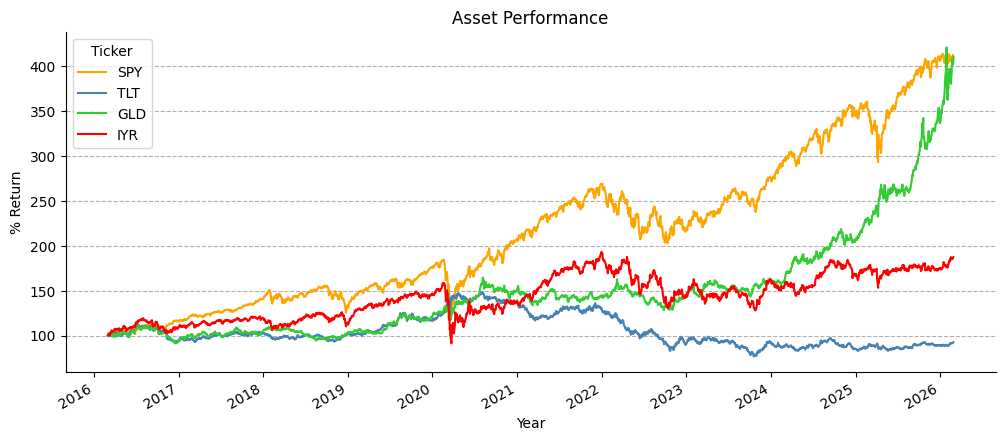

In [3]:
rebased = prices / prices.iloc[0] * 100

rebased.plot(kind='line', title='Asset Performance', color=['orange', 'steelblue', 'limegreen', 'red'])
plt.xlabel('Year')
plt.ylabel('% Return')
plt.grid(axis='y', linestyle='--')
plt.show()

## 3. Returns, Covariance & Correlation Matrix

Annualised Expected Returns:
Ticker
SPY    0.1572
TLT    0.0035
GLD    0.1539
IYR    0.0838
dtype: float64

Annualised Covariance Matrix:
Ticker     SPY     TLT     GLD     IYR
Ticker                                
SPY     0.0319 -0.0043  0.0018  0.0263
TLT    -0.0043  0.0222  0.0061  0.0015
GLD     0.0018  0.0061  0.0242  0.0043
IYR     0.0263  0.0015  0.0043  0.0412



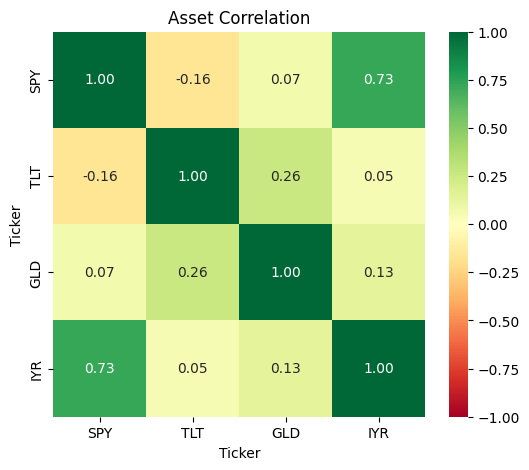

In [4]:
returns = prices.pct_change().dropna()

mean_daily = returns.mean()
mean_annual = mean_daily * TRADING_DAYS

cov_daily = returns.cov()
cov_annual = cov_daily * TRADING_DAYS

corr_matrix = returns.corr()

print('Annualised Expected Returns:')
print(mean_annual.round(4))
print()

print('Annualised Covariance Matrix:')
print(cov_annual.round(4))
print()

import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt='.2f')
plt.title('Asset Correlation')
plt.show()


## 4. Two-Asset Markowitz Bullet: SPY & TLT

In [5]:
w_spy = np.arange(0, 1.01, 0.01).round(2)   # 0.00 -> 1.00
w_tlt = (1 - w_spy).round(2)

mu_spy = mean_annual['SPY']
mu_tlt = mean_annual['TLT']
var_spy = cov_annual.loc['SPY',  'SPY']
var_tlt = cov_annual.loc['TLT', 'TLT']
cov_spy_tlt = cov_annual.loc['SPY',  'TLT']

pf_return_2 = w_spy * mu_spy + w_tlt * mu_tlt
pf_var_2 = (w_spy**2 * var_spy + w_tlt**2 * var_tlt + 2 * w_spy * w_tlt * cov_spy_tlt)
pf_std_2 = np.sqrt(pf_var_2)

df_pf_2 = pd.DataFrame({
    'w_SPY': w_spy,
    'w_TLT': w_tlt,
    'Exp_Return': pf_return_2.round(4),
    'Std_Dev': pf_std_2.round(4)
})

print(f'Portfolios generated: {len(df_pf_2)}')
df_pf_2.head(10)

Portfolios generated: 101


,w_SPY,w_TLT,Exp_Return,Std_Dev
0,0.00,1.00,0.0035,0.1491
1,0.01,0.99,0.0050,0.1474
2,0.02,0.98,0.0065,0.1456
3,0.03,0.97,0.0081,0.1439
4,0.04,0.96,0.0096,0.1422
5,0.05,0.95,0.0111,0.1405
6,0.06,0.94,0.0127,0.1389
7,0.07,0.93,0.0142,0.1373
8,0.08,0.92,0.0157,0.1357
9,0.09,0.91,0.0173,0.1341


In [6]:
# Manual look up of MVP

# Scans the Std_Dev column and returns the index number of the row with the lowest value
mvp_2_idx = df_pf_2['Std_Dev'].idxmin()

# Uses that index number to pull out the full row from the dataframe 
mvp_2 = df_pf_2.loc[mvp_2_idx]

print('Minimum Variance Portfolio (SPY, TLT)')
print(f"  SPY  weight : {mvp_2['w_SPY']:.0%}")
print(f"  TLT weight : {mvp_2['w_TLT']:.0%}")
print(f"  Expected Return : {mvp_2['Exp_Return']:.2%}")
print(f"  Standard Deviation : {mvp_2['Std_Dev']:.2%}")

Minimum Variance Portfolio (SPY, TLT)
  SPY  weight : 41%
  TLT weight : 59%
  Expected Return : 6.65%
  Standard Deviation : 10.51%


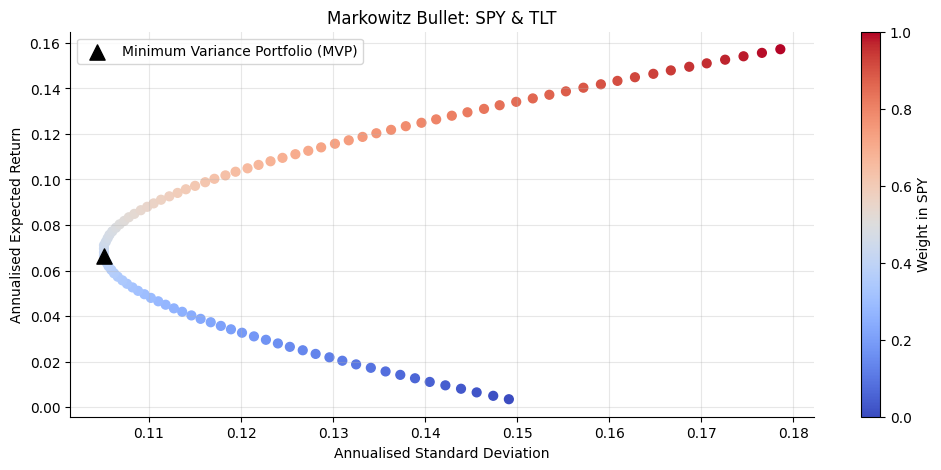

In [7]:
plt.scatter(df_pf_2['Std_Dev'], df_pf_2['Exp_Return'], c=df_pf_2['w_SPY'], cmap='coolwarm', s=40)
plt.colorbar(label='Weight in SPY')
plt.scatter(mvp_2['Std_Dev'], mvp_2['Exp_Return'], color='black', s=120, marker='^', label=f"Minimum Variance Portfolio (MVP)")
plt.title('Markowitz Bullet: SPY & TLT')
plt.xlabel('Annualised Standard Deviation')
plt.ylabel('Annualised Expected Return')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Optimisation 1: Global Minimum Variance Portfolio

In [8]:
# Generate 5,000 random portfolios
np.random.seed(42)
N = 5_000 # number of random portfolios to generate
n_assets = len(TICKERS)

rand_weights = np.random.dirichlet(np.ones(n_assets), size=N) # each row sums to 1

mu_vec = mean_annual.values # shape (4,)
cov_mat = cov_annual.values # shape (4,4)

rand_ret = rand_weights @ mu_vec
rand_std = np.sqrt(np.einsum('ij,jk,ik->i', rand_weights, cov_mat, rand_weights))
rand_sharpe = (rand_ret - RF) / rand_std

print(f'Random portfolios generated: {N}')

Random portfolios generated: 5000


In [9]:
from scipy.optimize import minimize

# Optimization helpers
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n_assets))
w0 = np.ones(n_assets) / n_assets

def port_std_fn(w):
    return np.sqrt(w @ cov_mat @ w)

# Minimum Variance Portfolio
res_mvp = minimize(port_std_fn, w0, method='SLSQP', bounds=bounds, constraints=constraints)
mvp_w = res_mvp.x
mvp_ret = mvp_w @ mu_vec
mvp_std = port_std_fn(mvp_w)

print('Minimum Variance Portfolio (SPY, TLT, GLD, IYR)')
for t, w in zip(TICKERS, mvp_w):
    print(f'  {t} weight : {w:.2%}')
print(f'  Expected Return : {mvp_ret:.2%}')
print(f'  Standard Deviation : {mvp_std:.2%}')

Minimum Variance Portfolio (SPY, TLT, GLD, IYR)
  SPY weight : 33.16%
  TLT weight : 41.22%
  GLD weight : 25.62%
  IYR weight : 0.00%
  Expected Return : 9.30%
  Standard Deviation : 9.65%


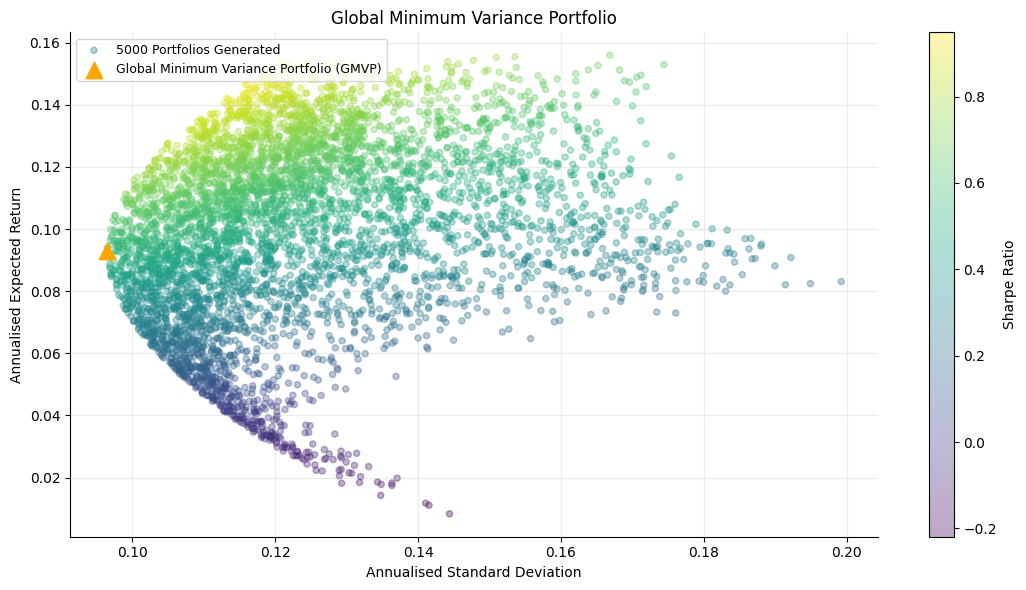

In [10]:
plt.figure(figsize=(11, 6))
plt.scatter(rand_std, rand_ret, c=rand_sharpe, cmap='viridis', alpha=0.35, s=20, label='5000 Portfolios Generated')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(mvp_std, mvp_ret, color='orange', s=140, marker='^', label='Global Minimum Variance Portfolio (GMVP)')
plt.title('Global Minimum Variance Portfolio')
plt.xlabel('Annualised Standard Deviation')
plt.ylabel('Annualised Expected Return')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Optimisation 2: Tangency Portfolio (Max Sharpe Ratio)

In [11]:
def neg_sharpe(w):
    ret = w @ mu_vec
    std = port_std_fn(w)
    return -(ret - RF) / std

# Tangency Portfolio (Max Sharpe Ratio)
res_tan = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=constraints)
tan_w = res_tan.x
tan_ret = tan_w @ mu_vec
tan_std = port_std_fn(tan_w)
tan_sharpe = (tan_ret - RF) / tan_std

print('Tangency Portfolio (Max Sharpe Ratio)')
for t, w in zip(TICKERS, tan_w):
    print(f'  {t} weight : {w:.2%}')
print(f'  Expected Return : {tan_ret:.2%}')
print(f'  Standard Deviation : {tan_std:.2%}')
print(f'  Sharpe Ratio : {tan_sharpe:.2f}')

Tangency Portfolio (Max Sharpe Ratio)
  SPY weight : 43.49%
  TLT weight : 0.00%
  GLD weight : 56.51%
  IYR weight : 0.00%
  Expected Return : 15.53%
  Standard Deviation : 12.11%
  Sharpe Ratio : 0.95


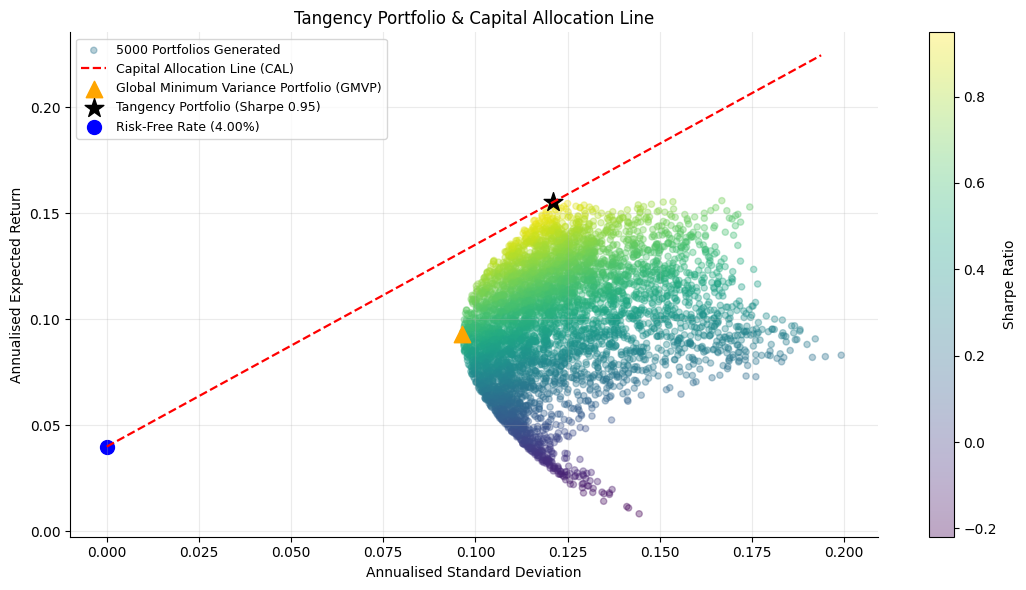

In [12]:
plt.figure(figsize=(11, 6))
plt.scatter(rand_std, rand_ret, c=rand_sharpe, cmap='viridis', alpha=0.35, s=20, label='5000 Portfolios Generated')
plt.colorbar(label='Sharpe Ratio')
x_cal = np.linspace(0, tan_std * 1.6, 100)
y_cal = RF + (tan_ret - RF) / tan_std * x_cal
plt.plot(x_cal, y_cal, color='red', linestyle='--', linewidth=1.6, label='Capital Allocation Line (CAL)')
plt.scatter(mvp_std, mvp_ret, color='orange', s=140, marker='^', label='Global Minimum Variance Portfolio (GMVP)')
plt.scatter(tan_std, tan_ret, color='black', s=200, marker='*', label=f'Tangency Portfolio (Sharpe {tan_sharpe:.2f})')
plt.scatter(0, RF, color='blue', s=100, label=f'Risk-Free Rate ({RF:.2%})')
plt.title('Tangency Portfolio & Capital Allocation Line')
plt.xlabel('Annualised Standard Deviation')
plt.ylabel('Annualised Expected Return')
plt.legend(loc='upper left', fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Optimisation 3: Minimum Variance with Target Return

In [13]:
TARGET_RETS = [0.10, 0.14, 0.18]
COLORS_OPT3 = ['steelblue', 'limegreen', 'red']

opt3_results = []

for mu_target in TARGET_RETS:
    cons = (
        {'type': 'eq', 'fun': lambda w:       np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, m=mu_target: w @ mu_vec - m}
    )
    res = minimize(port_std_fn, w0, method='SLSQP', bounds=bounds, constraints=cons)
    w   = res.x
    ret = w @ mu_vec
    std = port_std_fn(w)
    opt3_results.append({'mu_target': mu_target, 'w': w, 'ret': ret, 'std': std})

    print(f'Minimum Variance Portfolio | Target Return = {mu_target:.0%}')
    for t, wi in zip(TICKERS, w):
        print(f'  {t} weight : {wi:.2%}')
    print(f'  Expected Return : {ret:.2%}')
    print(f'  Standard Deviation : {std:.2%}')
    print()

Minimum Variance Portfolio | Target Return = 10%
  SPY weight : 34.32%
  TLT weight : 36.57%
  GLD weight : 29.11%
  IYR weight : 0.00%
  Expected Return : 10.00%
  Standard Deviation : 9.68%

Minimum Variance Portfolio | Target Return = 14%
  SPY weight : 40.77%
  TLT weight : 10.11%
  GLD weight : 49.12%
  IYR weight : 0.00%
  Expected Return : 14.00%
  Standard Deviation : 11.11%

Minimum Variance Portfolio | Target Return = 18%
  SPY weight : 100.00%
  TLT weight : 0.00%
  GLD weight : 0.00%
  IYR weight : 0.00%
  Expected Return : 15.72%
  Standard Deviation : 17.86%



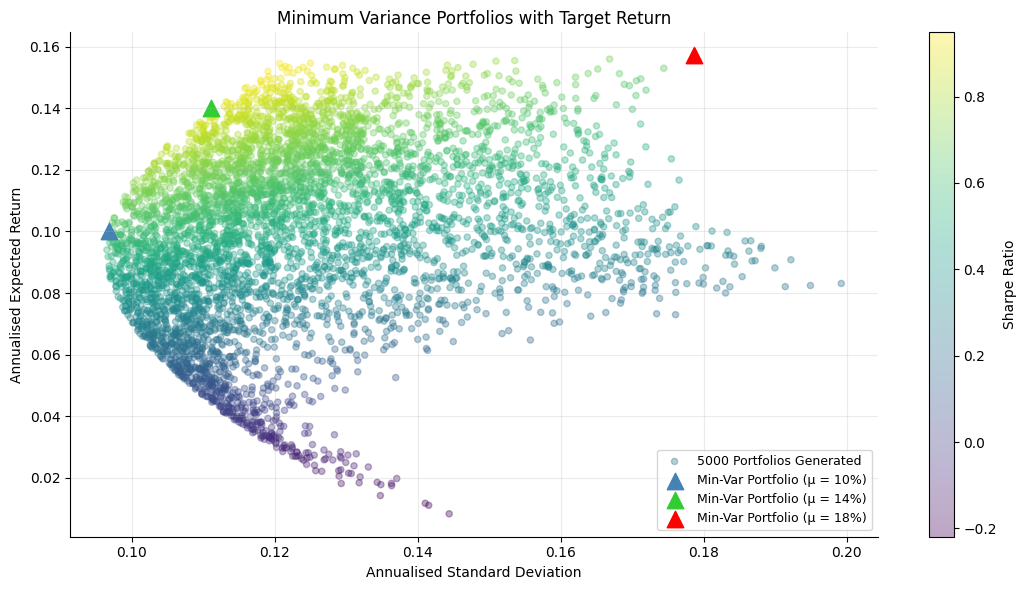

In [14]:
plt.figure(figsize=(11, 6))
plt.scatter(rand_std, rand_ret, c=rand_sharpe, cmap='viridis', alpha=0.35, s=20, label='5000 Portfolios Generated')
plt.colorbar(label='Sharpe Ratio')

for res, color in zip(opt3_results, COLORS_OPT3):
    plt.scatter(res['std'], res['ret'], color=color, s=140, marker='^', label=f"Min-Var Portfolio (μ = {res['mu_target']:.0%})")

plt.title('Minimum Variance Portfolios with Target Return')
plt.xlabel('Annualised Standard Deviation')
plt.ylabel('Annualised Expected Return')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Optimisation 4: Mean-Variance Utility

In [15]:
A_VALUES   = [-2, 0, 3]

def neg_utility(w, A):
    ret = w @ mu_vec
    var = w @ cov_mat @ w
    return -(ret - 0.5 * A * var)

opt4_results = []

for A in A_VALUES:
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    res = minimize(neg_utility, w0, args=(A,), method='SLSQP', bounds=bounds, constraints=cons)
    w = res.x
    ret = w @ mu_vec
    std = port_std_fn(w)
    utility = ret - 0.5 * A * (std ** 2)
    opt4_results.append({'A': A, 'w': w, 'ret': ret, 'std': std, 'utility': utility})

    print(f'Mean-Variance Utility Portfolio | A = {A}')
    for t, wi in zip(TICKERS, w):
        print(f'  {t} weight : {wi:.2%}')
    print(f'  Expected Return : {ret:.2%}')
    print(f'  Standard Deviation : {std:.2%}')
    print(f'  Utility : {utility:.4f}')
    print()

Mean-Variance Utility Portfolio | A = -2
  SPY weight : 100.00%
  TLT weight : 0.00%
  GLD weight : 0.00%
  IYR weight : 0.00%
  Expected Return : 15.72%
  Standard Deviation : 17.86%
  Utility : 0.1891

Mean-Variance Utility Portfolio | A = 0
  SPY weight : 100.00%
  TLT weight : 0.00%
  GLD weight : 0.00%
  IYR weight : 0.00%
  Expected Return : 15.72%
  Standard Deviation : 17.86%
  Utility : 0.1572

Mean-Variance Utility Portfolio | A = 3
  SPY weight : 44.78%
  TLT weight : 0.00%
  GLD weight : 55.22%
  IYR weight : 0.00%
  Expected Return : 15.53%
  Standard Deviation : 12.12%
  Utility : 0.1333



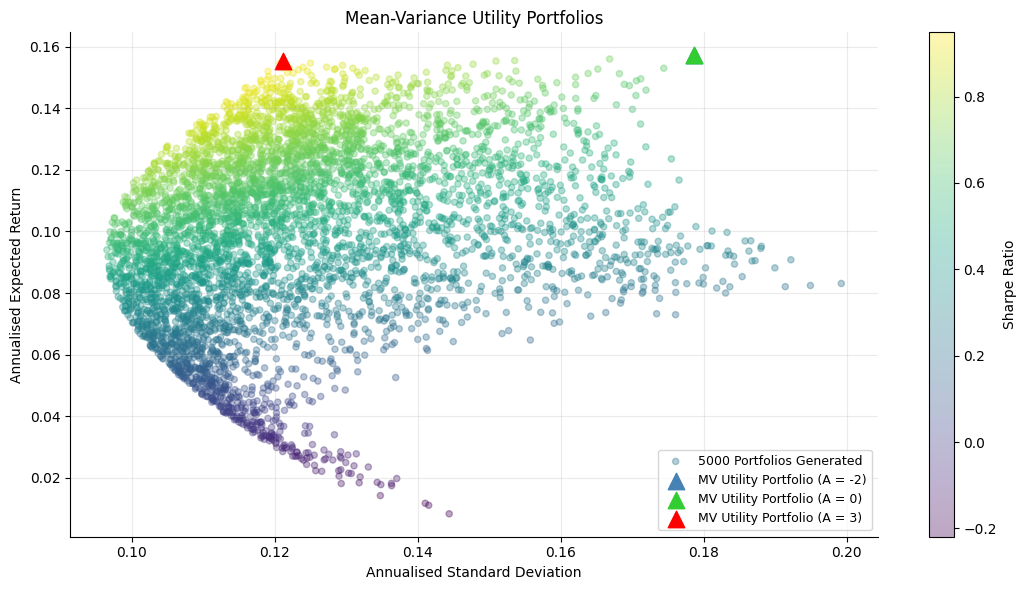

In [16]:
plt.figure(figsize=(11, 6))
plt.scatter(rand_std, rand_ret, c=rand_sharpe, cmap='viridis', alpha=0.35, s=20, label='5000 Portfolios Generated')
plt.colorbar(label='Sharpe Ratio')

for res, color in zip(opt4_results, COLORS_OPT3):
    label_str = f"MV Utility Portfolio (A = {res['A']})"
    plt.scatter(res['std'], res['ret'], color=color, s=140, marker='^', label=label_str)

plt.title('Mean-Variance Utility Portfolios')
plt.xlabel('Annualised Standard Deviation')
plt.ylabel('Annualised Expected Return')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. Forward-Looking Risk: Monte Carlo Simulation

In [17]:
# Monte carlo simulation done with the tangency portfolio
SIM_HORIZON = 252 # trading days in 1 year
N_SIM = 10_000
INITIAL = 1_000_000

def monte_carlo(weights, mu_annual, cov_annual,
                horizon=SIM_HORIZON, n_sim=N_SIM, initial=INITIAL):
    """Simulate portfolio value paths using correlated daily returns."""
    w = np.asarray(weights)
    mu_d = mu_annual.values  / TRADING_DAYS
    cov_d = cov_annual.values / TRADING_DAYS
    L = np.linalg.cholesky(cov_d)
    paths = np.zeros((n_sim, horizon + 1))
    paths[:, 0] = initial
    for t in range(1, horizon + 1):
        z = np.random.randn(n_sim, len(w))
        r = (z @ L.T + mu_d) @ w
        paths[:, t] = paths[:, t-1] * (1 + r)
    return paths

np.random.seed(42)
paths = monte_carlo(tan_w, mean_annual, cov_annual)
final = paths[:, -1]
pcts = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)

print('Monte Carlo Simulation Summary')
print(f'  Simulations : {N_SIM:,}')
print(f'  Horizon : {SIM_HORIZON} trading days in 1 year)')
print(f'  Initial : {INITIAL:,.0f}')
print()
pf = np.percentile(final, [5, 25, 50, 75, 95])
for p, v in zip([5, 25, 50, 75, 95], pf):
    print(f'  {p:3d}th pct : {v:>12,.0f}')

Monte Carlo Simulation Summary
  Simulations : 10,000
  Horizon : 252 trading days in 1 year)
  Initial : 1,000,000

    5th pct :      953,016
   25th pct :    1,067,443
   50th pct :    1,156,914
   75th pct :    1,257,914
   95th pct :    1,409,289


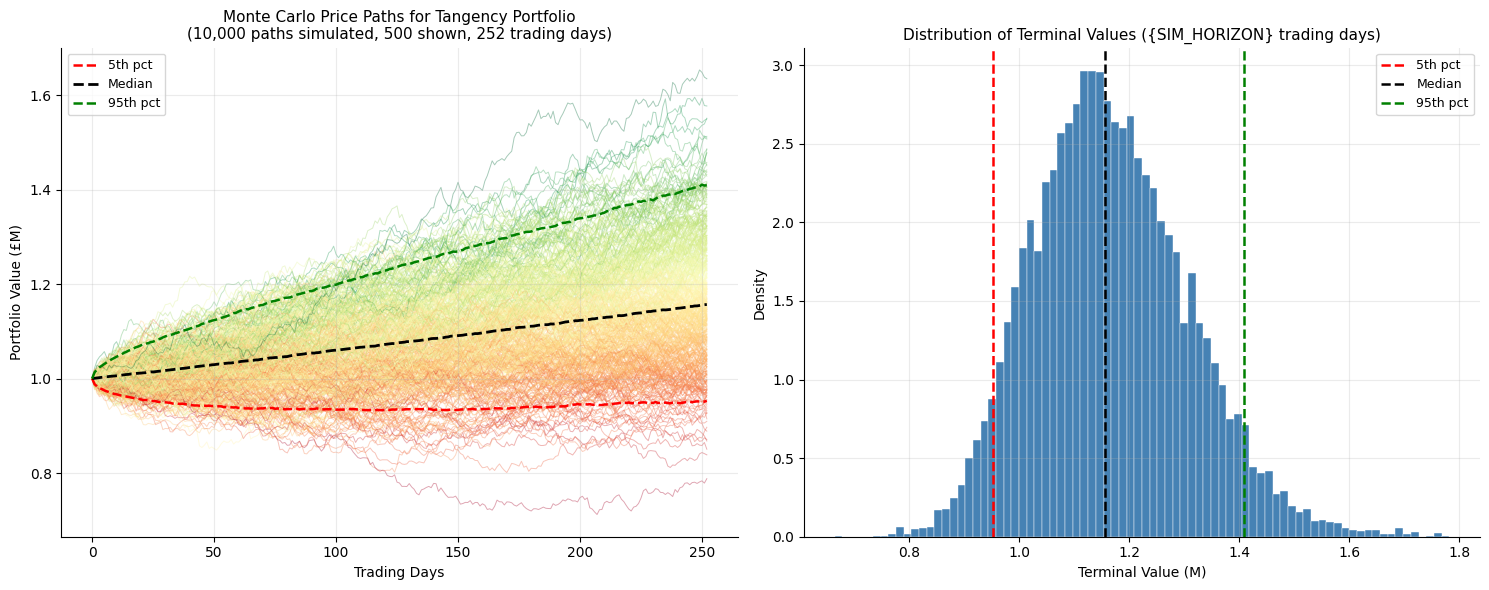

In [18]:
t_ax = np.arange(SIM_HORIZON + 1)
n_show = 500
idx = np.random.choice(N_SIM, n_show, replace=False)
t_vals = paths[idx, -1]
t_norm = (t_vals - t_vals.min()) / (t_vals.max() - t_vals.min())
cmap_paths = plt.cm.RdYlGn

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price paths
for j, k in enumerate(idx):
    axes[0].plot(t_ax, paths[k] / 1e6, color=cmap_paths(t_norm[j]), alpha=0.35, lw=0.7, zorder=1)

axes[0].plot(t_ax, pcts[0] / 1e6, '--',  lw=1.8, color='red',   zorder=3, label='5th pct')
axes[0].plot(t_ax, pcts[2] / 1e6, 'k--', lw=2.0,                zorder=3, label='Median')
axes[0].plot(t_ax, pcts[4] / 1e6, '--',  lw=1.8, color='green', zorder=3, label='95th pct')
axes[0].set_title(
    f'Monte Carlo Price Paths for Tangency Portfolio\n'
    f'({N_SIM:,} paths simulated, {n_show} shown, {SIM_HORIZON} trading days)',
    fontsize=11)
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Portfolio Value (£M)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.25)

# Terminal value distribution
axes[1].hist(final / 1e6, bins=80, color='steelblue', edgecolor='white', lw=0.3, density=True)
for p, col, lbl in [(5, 'red', '5th pct'), (50, 'black', 'Median'), (95, 'green', '95th pct')]:
    axes[1].axvline(np.percentile(final, p) / 1e6, color=col, lw=1.8, ls='--', label=lbl)
axes[1].set_xlabel('Terminal Value (M)')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Terminal Values ({SIM_HORIZON} trading days)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 10. Forward-Looking Risk: Value at Risk (VaR) & CVaR / Expected Shortfall

In [19]:
from scipy.stats import norm
import matplotlib.ticker as mtick

# Portfolios to compare
util_a3_w = next(r['w'] for r in opt4_results if r['A'] == 3)

key_portfs = {
    'GMVP' : mvp_w,
    'Tangency' : tan_w,
    'Utility A=3' : util_a3_w,
    'Equal Weight' : np.ones(n_assets) / n_assets,
}

BAR_COLORS = ['orange', 'steelblue', 'limegreen', 'red']

# Monte Carlo 1-day VaR/CVaR helper
def mc_var(weights, conf_levels=(0.95, 0.99), n_sim=10_000):
    """Simulate 1-day returns and compute VaR/CVaR from the distribution."""
    w = np.asarray(weights)
    mu_d = mu_vec  / TRADING_DAYS
    cov_d = cov_mat / TRADING_DAYS
    L = np.linalg.cholesky(cov_d)
    z = np.random.randn(n_sim, len(w))
    r_sim = (z @ L.T + mu_d) @ w
    results = {}
    for cl in conf_levels:
        alpha   = 1 - cl
        var_mc  = -np.percentile(r_sim, alpha * 100)
        mask    = r_sim <= -var_mc
        cvar_mc = -r_sim[mask].mean() if mask.any() else var_mc
        results[cl] = (var_mc, cvar_mc)
    return results

# Risk table
np.random.seed(42)
rows_risk = []

for nm, w in key_portfs.items():
    r = returns.values @ w

    # Historical
    var95_h = -np.percentile(r, 5)
    var99_h = -np.percentile(r, 1)
    cvar95_h = -r[r <= -var95_h].mean() if (r <= -var95_h).any() else var95_h
    cvar99_h = -r[r <= -var99_h].mean() if (r <= -var99_h).any() else var99_h

    # Parametric (normal)
    mu_r, sig_r = r.mean(), r.std()
    var95_p  = -(mu_r + norm.ppf(0.05) * sig_r)
    cvar95_p = -(mu_r - sig_r * norm.pdf(norm.ppf(0.05)) / 0.05)
    var99_p  = -(mu_r + norm.ppf(0.01) * sig_r)
    cvar99_p = -(mu_r - sig_r * norm.pdf(norm.ppf(0.01)) / 0.01)

    # Monte Carlo
    mc = mc_var(w)
    var95_mc,  cvar95_mc  = mc[0.95]
    var99_mc,  cvar99_mc  = mc[0.99]

    ann_ret = w @ mu_vec
    ann_std = port_std_fn(w)
    sharpe = (ann_ret - RF) / ann_std

    rows_risk.append({
        'Portfolio'     : nm,
        'Ann. Return'   : f'{ann_ret:.2%}',
        'Ann. Std Dev'  : f'{ann_std:.2%}',
        'Sharpe'        : f'{sharpe:.3f}',
        'Hist VaR 95%'  : f'{var95_h:.2%}',
        'Hist CVaR 95%' : f'{cvar95_h:.2%}',
        'Hist VaR 99%'  : f'{var99_h:.2%}',
        'Hist CVaR 99%' : f'{cvar99_h:.2%}',
        'Param VaR 95%' : f'{var95_p:.2%}',
        'Param CVaR 95%': f'{cvar95_p:.2%}',
        'Param VaR 99%' : f'{var99_p:.2%}',
        'Param CVaR 99%': f'{cvar99_p:.2%}',
        'MC VaR 95%'    : f'{var95_mc:.2%}',
        'MC CVaR 95%'   : f'{cvar95_mc:.2%}',
        'MC VaR 99%'    : f'{var99_mc:.2%}',
        'MC CVaR 99%'   : f'{cvar99_mc:.2%}',
    })

risk_df = pd.DataFrame(rows_risk).set_index('Portfolio')

print('Historical:')
print(risk_df[['Ann. Return', 'Ann. Std Dev', 'Sharpe', 'Hist VaR 95%', 'Hist CVaR 95%', 'Hist VaR 99%', 'Hist CVaR 99%']].to_string())
print()
print('Parametric:')
print(risk_df[['Param VaR 95%', 'Param CVaR 95%', 'Param VaR 99%', 'Param CVaR 99%']].to_string())
print()
print('Monte Carlo:')
print(risk_df[['MC VaR 95%', 'MC CVaR 95%', 'MC VaR 99%', 'MC CVaR 99%']].to_string())

Historical:
             Ann. Return Ann. Std Dev Sharpe Hist VaR 95% Hist CVaR 95% Hist VaR 99% Hist CVaR 99%
Portfolio                                                                                         
GMVP               9.30%        9.65%  0.549        0.97%         1.38%        1.56%         2.12%
Tangency          15.53%       12.11%  0.952        1.10%         1.76%        2.07%         3.03%
Utility A=3       15.53%       12.12%  0.952        1.10%         1.76%        2.03%         3.04%
Equal Weight       9.96%       10.92%  0.545        1.06%         1.61%        1.80%         2.76%

Parametric:
             Param VaR 95% Param CVaR 95% Param VaR 99% Param CVaR 99%
Portfolio                                                             
GMVP                 0.96%          1.22%         1.38%          1.58%
Tangency             1.19%          1.51%         1.71%          1.97%
Utility A=3          1.19%          1.51%         1.71%          1.97%
Equal Weight         1.09%

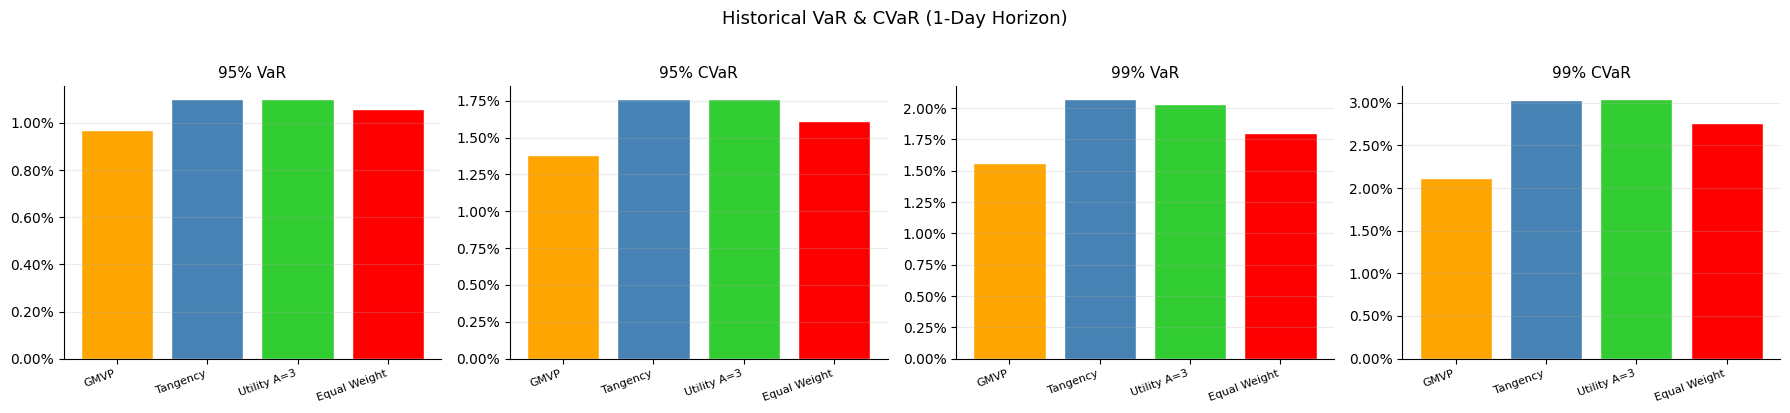

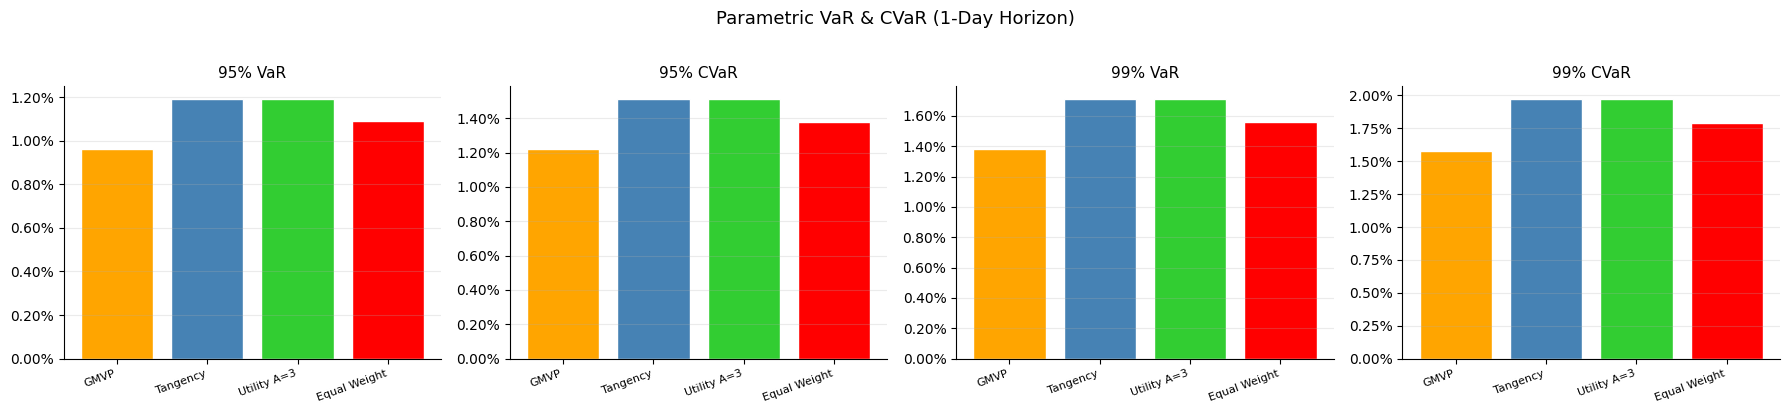

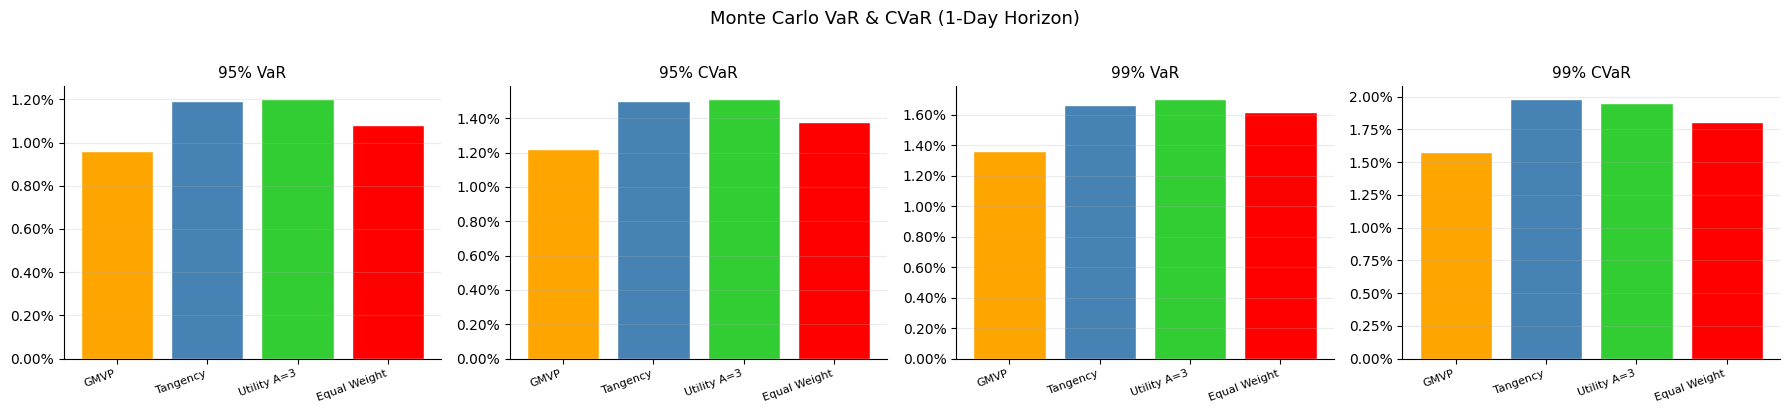

In [20]:
names = list(risk_df.index)

method_metrics = [
    ('Historical',  [('Hist VaR 95%',   '95% VaR'),  ('Hist CVaR 95%',   '95% CVaR'), ('Hist VaR 99%',   '99% VaR'),  ('Hist CVaR 99%',   '99% CVaR')]),
    ('Parametric',  [('Param VaR 95%',  '95% VaR'),  ('Param CVaR 95%',  '95% CVaR'), ('Param VaR 99%',  '99% VaR'),  ('Param CVaR 99%',  '99% CVaR')]),
    ('Monte Carlo', [('MC VaR 95%',     '95% VaR'),  ('MC CVaR 95%',     '95% CVaR'), ('MC VaR 99%',     '99% VaR'),  ('MC CVaR 99%',     '99% CVaR')]),
]

for method, metrics in method_metrics:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for i, (col, title) in enumerate(metrics):
        plt.sca(axes[i])
        vals = [float(risk_df.loc[nm, col].strip('%')) / 100 for nm in names]
        plt.bar(names, vals, color=BAR_COLORS, edgecolor='white')
        plt.title(title, fontsize=11)
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
        plt.xticks(range(len(names)), names, rotation=20, ha='right', fontsize=8)
        plt.grid(axis='y', alpha=0.25)
    plt.suptitle(f'{method} VaR & CVaR (1-Day Horizon)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


## 11. Historical Realised Performance: Backtest & Max Drawdown

In [21]:
# Portfolio weights
bt_portfolios = {
    'GMVP' : mvp_w,
    'Tangency' : tan_w,
    'Utility A=3' : next(r['w'] for r in opt4_results if r['A'] == 3),
    'Equal Weight' : np.ones(n_assets) / n_assets,
}

# Daily portfolio returns 
bt_returns = pd.DataFrame({
    nm: returns.values @ w for nm, w in bt_portfolios.items()
}, index=returns.index)

# Equity curves (rebased to 1)
bt_equity = (1 + bt_returns).cumprod()

# Max drawdown helper
def max_drawdown(equity_series):
    roll_max = equity_series.cummax()
    drawdown = equity_series / roll_max - 1
    return drawdown.min()

# Summary table
bt_rows = []
for nm, w in bt_portfolios.items():
    eq = bt_equity[nm]
    dr = bt_returns[nm]
    n_yr = len(dr) / TRADING_DAYS

    ann_ret = (eq.iloc[-1] ** (1 / n_yr)) - 1
    ann_std = dr.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_ret - RF) / ann_std
    mdd = max_drawdown(eq)
    tot_ret = eq.iloc[-1] - 1

    bt_rows.append({
        'Portfolio' : nm,
        **{t: f'{v:.1%}' for t, v in zip(TICKERS, w)},
        'Total Return' : f'{tot_ret:.2%}',
        'Ann. Return' : f'{ann_ret:.2%}',
        'Ann. Std Dev' : f'{ann_std:.2%}',
        'Sharpe Ratio' : f'{sharpe:.3f}',
        'Max Drawdown' : f'{mdd:.2%}',
    })

bt_df = pd.DataFrame(bt_rows).set_index('Portfolio')

print('Historical Backtest Summary:')
print(f'Period : {returns.index[0].date()} -> {returns.index[-1].date()}')
print(f'Days : {len(returns):,}  ({len(returns)/TRADING_DAYS:.1f} years)')
print()
print(bt_df.to_string())

Historical Backtest Summary:
Period : 2016-03-02 -> 2026-02-27
Days : 2,513  (10.0 years)

                SPY    TLT    GLD    IYR Total Return Ann. Return Ann. Std Dev Sharpe Ratio Max Drawdown
Portfolio                                                                                               
GMVP          33.2%  41.2%  25.6%   0.0%      141.21%       9.23%        9.65%        0.542      -24.65%
Tangency      43.5%   0.0%  56.5%   0.0%      337.16%      15.94%       12.11%        0.986      -18.90%
Utility A=3   44.8%   0.0%  55.2%   0.0%      337.30%      15.95%       12.12%        0.986      -19.18%
Equal Weight  25.0%  25.0%  25.0%  25.0%      154.27%       9.81%       10.92%        0.532      -24.80%


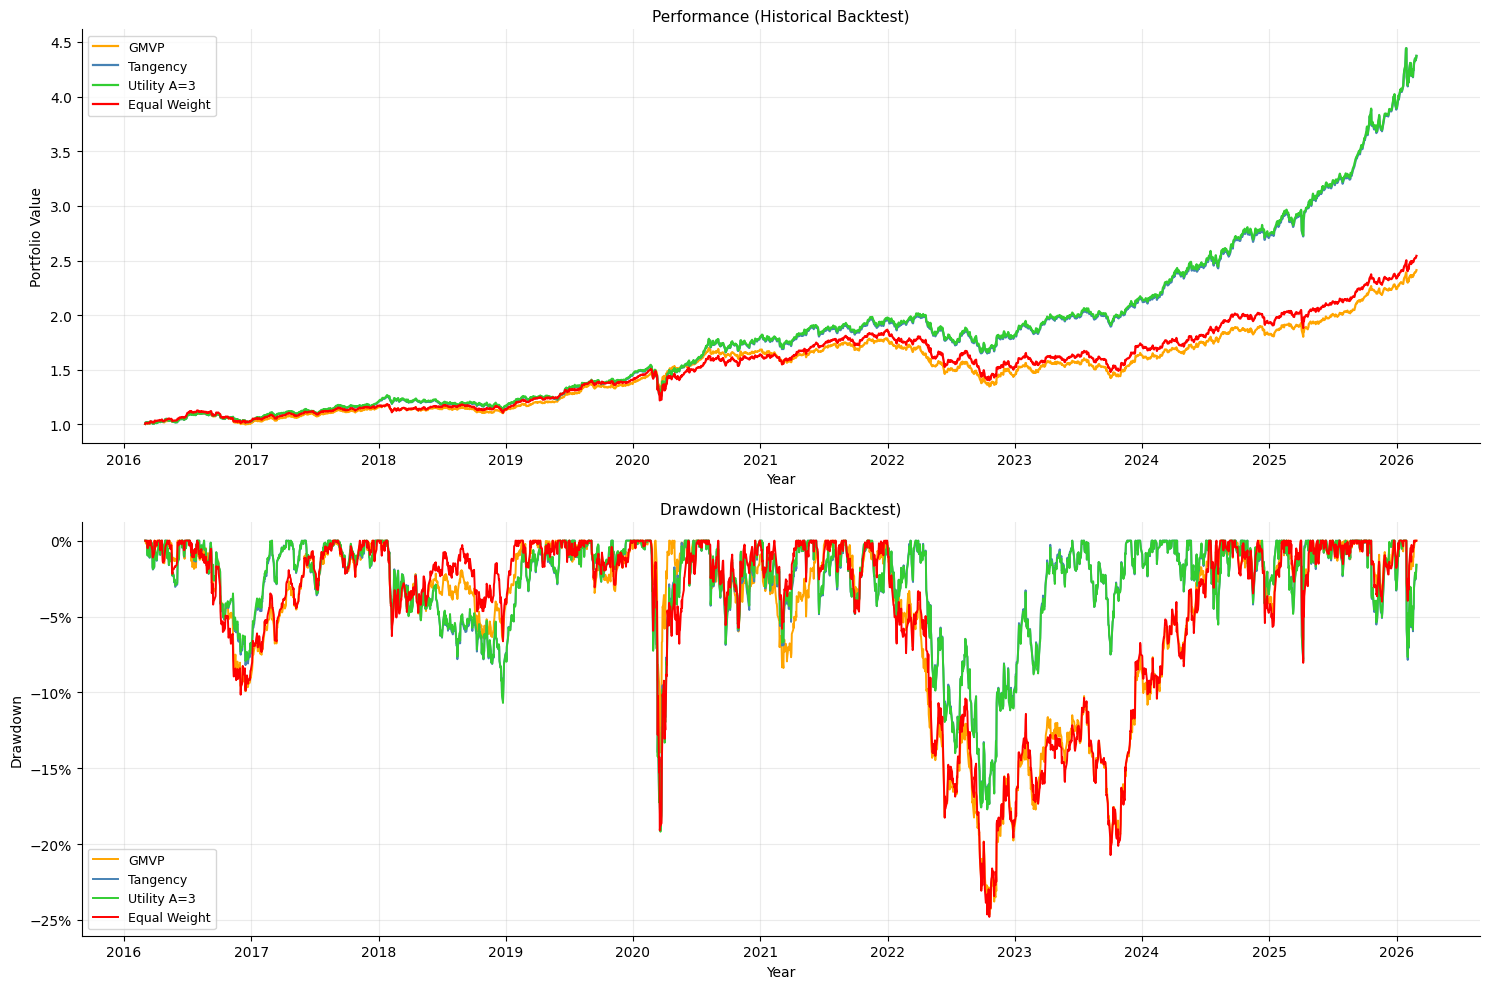

In [22]:
plt.figure(figsize=(15, 10))

# Equity curves
plt.subplot(2, 1, 1)
for (nm, _), col in zip(bt_portfolios.items(), BAR_COLORS):
    plt.plot(bt_equity.index, bt_equity[nm], label=nm, color=col, lw=1.6)
plt.title('Performance (Historical Backtest)', fontsize=11)
plt.xlabel('Year')
plt.ylabel('Portfolio Value')
plt.legend(fontsize=9)
plt.grid(alpha=0.25)

# Drawdown curves
plt.subplot(2, 1, 2)
for (nm, _), col in zip(bt_portfolios.items(), BAR_COLORS):
    roll_max = bt_equity[nm].cummax()
    drawdown = bt_equity[nm] / roll_max - 1
    plt.plot(bt_equity.index, drawdown, label=nm, color=col, lw=1.4)
plt.title('Drawdown (Historical Backtest)', fontsize=11)
plt.xlabel('Year')
plt.ylabel('Drawdown')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
plt.legend(fontsize=9)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()